# 03 · The Contract Efficiency Index

Building a composite index, and then doing the work that decides whether anyone should believe it.

A composite index carries three well-known problems. This notebook builds the index and then attacks each one:

1. **The weights are arbitrary** → re-score under 2,000 random weightings
2. **Normalisation is scale-dependent** → winsorise before scaling
3. **Aggregation hides the driver** → always return the sub-scores

In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT / "src"))

pd.set_option("display.width", 190)
pd.set_option("display.max_columns", 60)
pd.set_option("display.float_format", lambda v: f"{v:,.3f}")

# Categorical slots validated for colour-vision-deficiency separation and
# contrast against a light surface (see the project's dataviz palette).
BLUE, ORANGE, AQUA, RED = "#2a78d6", "#eb6834", "#1baf7a", "#e34948"
plt.rcParams.update({
    "figure.figsize": (10, 4.4), "figure.dpi": 110,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.alpha": 0.25, "grid.linewidth": 0.7,
    "axes.titlesize": 12, "axes.titleweight": "semibold",
    "font.size": 10, "axes.labelsize": 10,
})

CURATED = ROOT / "data" / "curated"
SAMPLES = ROOT / "data" / "samples"

def load(name):
    """Read a curated table, falling back to the committed sample CSV."""
    parquet = CURATED / f"{name}.parquet"
    if parquet.exists():
        return pd.read_parquet(parquet)
    return pd.read_csv(SAMPLES / f"{name}.csv")

print("pandas", pd.__version__, "| numpy", np.__version__)


pandas 2.0.3 | numpy 1.26.4


In [2]:
from fedspend.config import Config
from fedspend.metrics import efficiency_index as cei

cfg = Config.load(ROOT / 'config' / 'pipeline.yml')
idx = load('efficiency_index')
sens = load('index_sensitivity')
LATEST = int(cfg.latest_fy)
print(f'{len(idx)} agencies scored on FY{LATEST}')
print('dimensions:', ', '.join(cei.DIMENSIONS))

19 agencies scored on FY2025
dimensions: competition, pricing_risk, vendor_diversity, spend_discipline, stability


## 1. The dimensions

| Dimension | Raw measure (higher = more efficient) | Weight |
|---|---|---:|
| competition | share of obligations competed | 0.30 |
| pricing_risk | 1 − government-risk share | 0.25 |
| vendor_diversity | 1 − normalised vendor HHI | 0.20 |
| spend_discipline | 1 − September share | 0.15 |
| stability | 1 − real YoY growth volatility | 0.10 |

**Population:** agencies with ≥ $1B in the scored year. Ranking a percentage computed on a $111M base against one computed on a $492B base is not a comparison.

In [3]:
raw_cols = [f'{d}_raw' for d in cei.DIMENSIONS]
score_cols = [f'{d}_score' for d in cei.DIMENSIONS]
idx.set_index('agency_name')[raw_cols].round(3).sort_values('competition_raw', ascending=False)

,competition_raw,pricing_risk_raw,vendor_diversity_raw,spend_discipline_raw,stability_raw
agency_name,,,,,
Department of Energy,0.970,0.032,0.958,0.912,-1.211
Agency for International Development,0.968,0.086,0.888,0.861,-26.319
Department of Labor,0.966,0.794,0.975,0.767,-14.392
Environmental Protection Agency,0.930,0.538,0.981,0.784,-22.104
Department of Veterans Affairs,0.922,0.984,0.885,0.871,-4.401
General Services Administration,0.921,0.450,0.987,0.822,-10.916
Department of Homeland Security,0.910,0.802,0.991,0.574,-9.658
Department of Education,0.910,0.987,0.926,0.715,-10.257
Department of Agriculture,0.891,0.982,1.006,0.791,-11.860


## 2. Winsorise, then scale

Min-max scaling is scale-dependent: one extreme agency compresses everyone else into a narrow band. Clipping each dimension to its own 5th/95th percentiles first stops a single outlier from setting the range for the whole field.

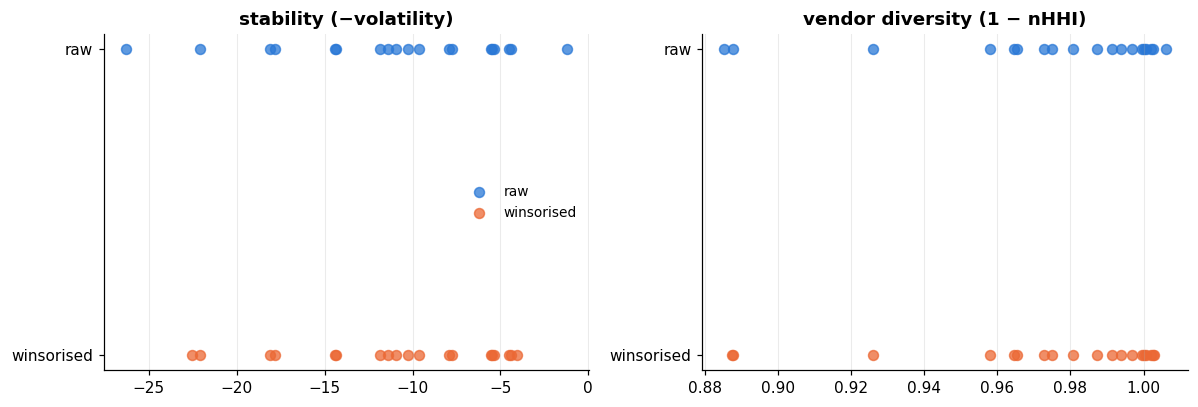

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.8))
for ax, col, title in zip(axes, ['stability_raw','vendor_diversity_raw'],
                          ['stability (−volatility)','vendor diversity (1 − nHHI)']):
    v = idx[col].dropna()
    w = cei.winsorize(v, 0.05, 0.95)
    ax.scatter(v, [1]*len(v), color=BLUE, alpha=.75, s=42, label='raw')
    ax.scatter(w, [0]*len(w), color=ORANGE, alpha=.75, s=42, label='winsorised')
    ax.set_yticks([0,1]); ax.set_yticklabels(['winsorised','raw'])
    ax.set_title(title); ax.grid(axis='y', alpha=0)
axes[0].legend(frameon=False, fontsize=9)
plt.tight_layout(); plt.show()

## 3. The scores

In [5]:
view = idx.set_index('agency_name')[score_cols + ['efficiency_index','rank']].sort_values('rank')
view.round(1)

,competition_score,pricing_risk_score,vendor_diversity_score,spend_discipline_score,stability_score,efficiency_index,rank
agency_name,,,,,,,
Department of Agriculture,76.000,99.700,100.000,70.800,57.800,84.100,1.000
Department of the Treasury,72.900,92.200,73.800,89.000,79.200,80.900,2.000
Department of Labor,99.400,78.900,75.900,62.400,44.100,78.500,3.000
Department of Veterans Affairs,85.800,100.000,0.000,98.500,98.300,75.300,4.000
Department of Justice,64.100,64.300,98.100,80.000,80.000,74.900,5.000
Department of the Interior,74.500,77.900,99.700,70.200,25.500,74.800,6.000
General Services Administration,85.300,40.900,86.600,81.500,62.900,71.600,7.000
Department of Transportation,52.300,62.000,92.200,70.200,97.600,69.900,8.000
Department of Education,82.000,100.000,33.400,44.400,66.500,69.600,9.000


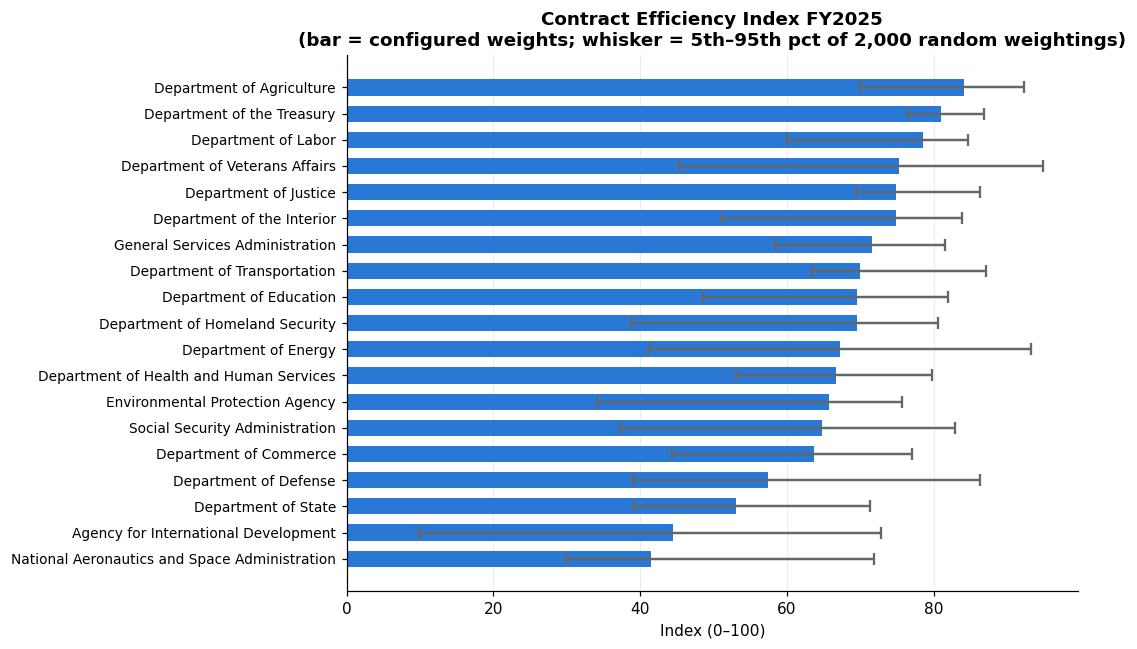

In [6]:
fig, ax = plt.subplots(figsize=(10, 6))
d = idx.sort_values('efficiency_index')
s = sens.set_index('agency_name').reindex(d.agency_name)
y = range(len(d))
ax.barh(y, d.efficiency_index, color=BLUE, height=.62, zorder=2)
ax.hlines(y, s.score_p05.values, s.score_p95.values, color='#666', lw=1.6, zorder=3)
ax.scatter(s.score_p05.values, y, marker='|', color='#666', s=70, zorder=3)
ax.scatter(s.score_p95.values, y, marker='|', color='#666', s=70, zorder=3)
ax.set_yticks(list(y)); ax.set_yticklabels(d.agency_name, fontsize=9)
ax.set(title=f'Contract Efficiency Index FY{LATEST}\n(bar = configured weights; whisker = 5th–95th pct of 2,000 random weightings)',
       xlabel='Index (0–100)')
ax.grid(axis='y', alpha=0)
plt.tight_layout(); plt.show()

## 4. Do the ranks survive a different weighting?

Weights are drawn from a flat Dirichlet — the uniform distribution over the simplex, so every weighting that sums to one is equally likely. If a rank moves twenty places across that distribution, the rank is an artefact of the chosen weights.

In [7]:
s = sens.sort_values('rank_median')
cols = ['agency_name','rank_median','rank_best','rank_worst','rank_iqr',
        'pct_draws_in_bottom_quartile','pct_draws_in_top_quartile','quartile_verdict']
s[cols].round(1).reset_index(drop=True)

,agency_name,rank_median,rank_best,rank_worst,rank_iqr,pct_draws_in_bottom_quartile,pct_draws_in_top_quartile,quartile_verdict
0,Department of Agriculture,3.000,1.000,12.000,5.000,0.000,71.200,robustly top quartile
1,Department of the Treasury,3.000,1.000,13.000,3.000,0.000,82.800,robustly top quartile
2,Department of Veterans Affairs,4.000,1.000,19.000,11.000,18.000,54.800,not separable
3,Department of Justice,5.000,1.000,14.000,4.000,0.000,59.700,not separable
4,Department of Energy,7.000,1.000,18.000,12.000,22.400,43.700,not separable
5,Department of Transportation,7.000,1.000,16.000,6.000,2.600,39.000,not separable
6,Department of Labor,8.000,1.000,15.000,6.000,0.300,27.300,not separable
7,General Services Administration,8.000,2.000,16.000,5.000,4.600,21.200,not separable
8,Department of the Interior,9.000,2.000,16.000,6.000,12.200,22.200,not separable
9,Department of Defense,9.000,1.000,19.000,9.000,23.800,26.600,not separable


In [8]:
verdicts = sens.quartile_verdict.value_counts()
print(verdicts.to_string())
print()
robust = sens[sens.quartile_verdict != 'not separable']
print(f'{len(robust)} of {len(sens)} agencies hold their quartile across the weighting distribution:')
for _, r in robust.iterrows():
    print(f'  {r.agency_name:<46} {r.quartile_verdict}')

quartile_verdict
not separable               15
robustly top quartile        2
robustly bottom quartile     2

4 of 19 agencies hold their quartile across the weighting distribution:
  Department of Agriculture                      robustly top quartile
  Department of the Treasury                     robustly top quartile
  Department of State                            robustly bottom quartile
  Agency for International Development           robustly bottom quartile


### This is the honest result, and it is the point

Most of the ranking does **not** survive a change of weights. Reporting the index as a clean 1-to-19 ordering would be presenting weighting choices as findings.

What *is* robust: the bottom of the table. Those agencies score poorly under almost any weighting anyone might reasonably choose, which is a result worth acting on. The middle is not separable and is reported as such.

## 5. Named alternative weightings

In [9]:
comparison = load('index_weighting_comparison')
comparison.round(1).reset_index(drop=True)

,agency_name,competition_only,configured,equal,risk_weighted,rank_spread
0,Agency for International Development,2.000,18.000,19.000,17.000,17.000
1,Department of Energy,1.000,11.000,6.000,15.000,14.000
2,Environmental Protection Agency,4.000,13.000,16.000,8.000,12.000
3,Department of Transportation,16.000,8.000,5.000,14.000,11.000
4,Department of the Treasury,12.000,2.000,1.000,3.000,11.000
5,Department of Justice,13.000,5.000,3.000,9.000,10.000
6,Department of Defense,19.000,16.000,10.000,18.000,9.000
7,Department of Agriculture,9.000,1.000,2.000,1.000,8.000
8,Department of Homeland Security,7.000,10.000,13.000,7.000,6.000
9,Department of the Interior,10.000,6.000,9.000,5.000,5.000


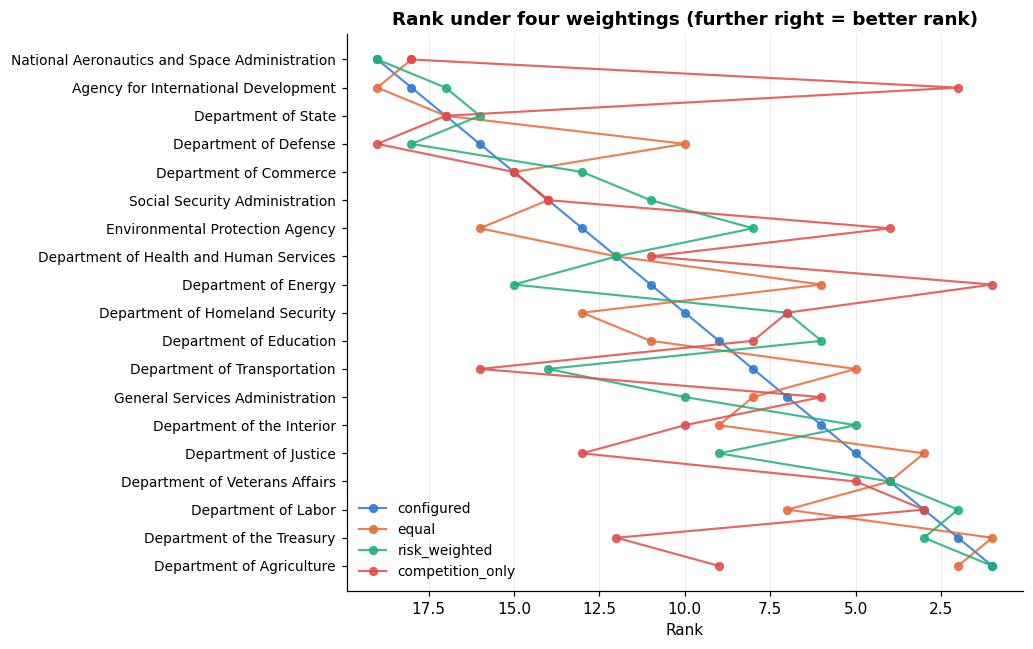

In [10]:
wide = comparison.set_index('agency_name')
cols = [c for c in ['configured','equal','risk_weighted','competition_only'] if c in wide.columns]
fig, ax = plt.subplots(figsize=(9.5, 6))
order = wide.sort_values('configured').index
for i, c in enumerate(cols):
    ax.plot(wide.loc[order, c].values, range(len(order)), 'o-',
            color=[BLUE, ORANGE, AQUA, RED][i], lw=1.4, ms=5, alpha=.85, label=c)
ax.set_yticks(range(len(order))); ax.set_yticklabels(order, fontsize=9)
ax.invert_xaxis()
ax.set(title='Rank under four weightings (further right = better rank)', xlabel='Rank')
ax.legend(frameon=False, fontsize=9); ax.grid(axis='y', alpha=0)
plt.tight_layout(); plt.show()

## 6. Decomposing any score

A composite that cannot be taken apart is not usable. Every score returns its sub-scores, so 'why is this agency here' is always answerable.

In [11]:
target = idx.sort_values('efficiency_index').iloc[0]['agency_name']
row = idx.set_index('agency_name').loc[target]
weights = cfg['efficiency_index']['weights']
parts = pd.DataFrame({
    'sub-score': [row[f'{d}_score'] for d in cei.DIMENSIONS],
    'weight':    [weights[d] for d in cei.DIMENSIONS],
}, index=list(cei.DIMENSIONS))
parts['contribution'] = parts['sub-score'] * parts['weight']
print(f'{target}  —  index {row.efficiency_index:.1f}')
display(parts.round(2))
print(f'sum of contributions: {parts.contribution.sum():.1f}')

National Aeronautics and Space Administration  —  index 41.4


,sub-score,weight,contribution
competition,4.140,0.300,1.240
pricing_risk,27.800,0.250,6.950
vendor_diversity,66.880,0.200,13.380
spend_discipline,70.740,0.150,10.610
stability,92.510,0.100,9.250


sum of contributions: 41.4


---

## What the index is for

It is a **triage device** that ranks where to look first. It is not a measure of waste, and a low score is not an accusation — a defence research agency buying developmental systems *should* run more cost-reimbursement work and a thinner vendor base than an agency buying office supplies.

See [`docs/LIMITATIONS.md`](../docs/LIMITATIONS.md).